# Top-20 Unique Kalman Portfolio vs SPY (Out-of-Sample)

This notebook rebuilds a portfolio from the 20 unique symbols in `top20_unique_equities_30_60_1y.csv`, applies each symbol's best parameters, and compares equal-weight portfolio performance against SPY.

It is designed for an out-of-sample window so you can test historical robustness.

In [8]:
import os
from pathlib import Path
from datetime import datetime, timedelta, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [21]:
# Paths and runtime configuration
BASE_DIR = Path.cwd()
CSV_PATH = BASE_DIR / 'top20_unique_equities_30_60_1y.csv'

# Evaluation mode
# - 'in_sample': last 1 year (same horizon used in selection)
# - 'out_of_sample': longer 2-year window for robustness checks
EVAL_MODE = 'in_sample'

END_DT = datetime.now(timezone.utc) - timedelta(days=1)
if EVAL_MODE == 'in_sample':
    START_DT = END_DT - timedelta(days=365)
else:
    START_DT = END_DT - timedelta(days=730)

RISK_FREE_RATE_ANNUAL = 0.04
TRADING_COST_BPS_PER_TURNOVER = 2.0  # 2 bps per 1x notional turnover
MIN_SYMBOL_COVERAGE = 0.90           # Require each symbol to cover at least 90% of benchmark bars
RTH_TIMEZONE = 'America/New_York'
RTH_START = '09:30'
RTH_END = '16:00'
BENCHMARK_SYMBOL = 'SPY'             # Set to 'VTI' for broader market benchmark

# Load credentials
load_dotenv((BASE_DIR / '../../.env').resolve())
API_KEY = os.getenv('ALPACA_API_KEY')
API_SECRET = os.getenv('ALPACA_API_SECRET')

if not API_KEY or not API_SECRET:
    raise RuntimeError('Missing Alpaca credentials in .env')

client = StockHistoricalDataClient(API_KEY, API_SECRET)

top20 = pd.read_csv(CSV_PATH)
top20 = top20.sort_values('sharpe', ascending=False).drop_duplicates('symbol').head(20).reset_index(drop=True)

print(f'Loaded {len(top20)} unique symbols from {CSV_PATH.name}')
print(f'Mode: {EVAL_MODE}')
print(f'Benchmark: {BENCHMARK_SYMBOL}')
print(f'Window: {START_DT} -> {END_DT}')
display(top20[['symbol', 'timeframe', 'm_var', 'z_thresh', 'window', 'sharpe', 'total_return', 'alpha', 'win_rate', 'total_trades']])

Loaded 20 unique symbols from top20_unique_equities_30_60_1y.csv
Mode: in_sample
Benchmark: SPY
Window: 2025-03-18 17:11:43.535778+00:00 -> 2026-03-18 17:11:43.535778+00:00


,symbol,timeframe,m_var,z_thresh,window,sharpe,total_return,alpha,win_rate,total_trades
0,KMI,30Min,0.001,1.0,10,6.879749,5.488741,5.479587,0.534280,2078
1,DOC,30Min,0.001,1.0,20,6.581039,5.465762,5.448367,0.537172,1580
2,EXC,30Min,0.001,1.5,10,6.259835,3.275557,3.267608,0.526297,1416
3,EQT,30Min,0.001,1.0,10,6.199081,10.919451,10.902190,0.534067,2135
4,MDT,30Min,0.001,2.0,10,6.133883,2.552079,2.541969,0.549891,1147
5,CNP,30Min,0.001,2.0,20,5.737610,1.953193,1.955358,0.516868,785
6,NEE,30Min,0.001,1.0,10,5.601362,3.570591,3.552205,0.534842,2253
7,VTRS,30Min,0.001,1.0,10,5.547933,6.271264,6.257316,0.528593,1687
8,PCG,30Min,0.001,1.0,20,5.468865,3.652178,3.646527,0.532292,1920
9,DUK,30Min,0.001,2.0,10,5.463892,1.633577,1.633153,0.535383,1187


In [10]:
class SingleStateKalmanFilter:
    def __init__(self, process_variance, estimated_measurement_variance):
        self.process_variance = process_variance
        self.estimated_measurement_variance = estimated_measurement_variance
        self.posteri_estimate = 0.0
        self.posteri_error_estimate = 1.0

    def input_latest_measurement(self, measurement):
        priori_estimate = self.posteri_estimate
        priori_error_estimate = self.posteri_error_estimate + self.process_variance
        blending_factor = priori_error_estimate / (priori_error_estimate + self.estimated_measurement_variance)
        self.posteri_estimate = priori_estimate + blending_factor * (measurement - priori_estimate)
        self.posteri_error_estimate = (1 - blending_factor) * priori_error_estimate
        return self.posteri_estimate


def run_kalman_iteration(close_series, p_var, m_var, z_thresh, wd, return_position=False):
    if close_series.empty or len(close_series) < wd + 5:
        return (pd.Series(dtype=float), pd.Series(dtype=float)) if return_position else pd.Series(dtype=float)

    kf = SingleStateKalmanFilter(p_var, m_var)
    kf.posteri_estimate = float(close_series.iloc[0])

    errors = np.zeros(len(close_series), dtype=float)
    vals = close_series.values.astype(float)

    for i, p in enumerate(vals):
        k = kf.input_latest_measurement(p)
        errors[i] = p - k

    df_temp = pd.DataFrame({'price': vals, 'error': errors}, index=close_series.index)
    df_temp['error_std'] = df_temp['error'].rolling(window=int(wd)).std()

    z_scores = np.zeros(len(df_temp), dtype=float)
    std_vals = df_temp['error_std'].values
    mask = std_vals != 0
    z_scores[mask] = df_temp['error'].values[mask] / std_vals[mask]

    positions = np.zeros(len(df_temp), dtype=float)
    current_pos = 0

    for i, z in enumerate(z_scores):
        if z > z_thresh and current_pos <= 0:
            current_pos = -1
        elif z < -z_thresh and current_pos >= 0:
            current_pos = 1
        elif current_pos == -1 and z < 0:
            current_pos = 0
        elif current_pos == 1 and z > 0:
            current_pos = 0
        positions[i] = current_pos

    position = pd.Series(positions, index=df_temp.index).shift(1).fillna(0.0)
    returns = position * df_temp['price'].pct_change().fillna(0.0)
    returns.name = 'returns'

    if return_position:
        position.name = 'position'
        return returns, position

    return returns


def max_drawdown(returns):
    eq = (1 + returns).cumprod()
    dd = eq / eq.cummax() - 1
    return float(dd.min()), dd


def bars_per_year_from_index(index):
    if len(index) < 3:
        return 252 * 13

    deltas = index.to_series().diff().dropna()
    med = deltas.median()
    minutes = med.total_seconds() / 60.0

    if minutes <= 30:
        return int(252 * 13)
    if minutes <= 60:
        return int(252 * 6.5)
    return 252


def performance_metrics(portfolio_returns, benchmark_returns, rf_annual=0.04):
    aligned = pd.concat([portfolio_returns.rename('p'), benchmark_returns.rename('b')], axis=1).dropna()
    p = aligned['p']
    b = aligned['b']

    ppy = bars_per_year_from_index(aligned.index)
    rf_per = rf_annual / ppy

    p_total = float((1 + p).prod() - 1)
    b_total = float((1 + b).prod() - 1)

    years = max((aligned.index[-1] - aligned.index[0]).days / 365.25, 1 / 365.25)
    p_cagr = float((1 + p_total) ** (1 / years) - 1)
    b_cagr = float((1 + b_total) ** (1 / years) - 1)

    p_vol = float(p.std(ddof=0) * np.sqrt(ppy))
    b_vol = float(b.std(ddof=0) * np.sqrt(ppy))

    p_excess = p - rf_per

    sharpe = float((p_excess.mean() / p.std(ddof=0)) * np.sqrt(ppy)) if p.std(ddof=0) > 0 else np.nan

    p_down = p[p < 0]
    sortino = float((p_excess.mean() / p_down.std(ddof=0)) * np.sqrt(ppy)) if len(p_down) > 1 and p_down.std(ddof=0) > 0 else np.nan

    cov = float(np.cov(p, b, ddof=0)[0, 1]) if len(aligned) > 1 else np.nan
    var_b = float(np.var(b, ddof=0)) if len(aligned) > 1 else np.nan
    beta = cov / var_b if var_b and var_b > 0 else np.nan

    alpha_per = float(p.mean() - (rf_per + beta * (b.mean() - rf_per))) if pd.notna(beta) else np.nan
    alpha_annual = float(alpha_per * ppy) if pd.notna(alpha_per) else np.nan

    tracking_error = float((p - b).std(ddof=0) * np.sqrt(ppy))
    info_ratio = float(((p - b).mean() * ppy) / tracking_error) if tracking_error > 0 else np.nan

    mdd, dd_series = max_drawdown(p)
    calmar = float(p_cagr / abs(mdd)) if mdd < 0 else np.nan

    wins = p[p > 0]
    losses = p[p < 0]
    win_rate = float((p > 0).mean())
    profit_factor = float(wins.sum() / abs(losses.sum())) if abs(losses.sum()) > 0 else np.nan

    var_95 = float(np.percentile(p, 5))
    cvar_95 = float(p[p <= var_95].mean()) if (p <= var_95).any() else np.nan

    capture_up = float(p[b > 0].mean() / b[b > 0].mean()) if (b > 0).any() and abs(b[b > 0].mean()) > 0 else np.nan
    capture_down = float(p[b < 0].mean() / b[b < 0].mean()) if (b < 0).any() and abs(b[b < 0].mean()) > 0 else np.nan

    return {
        'Portfolio Total Return': p_total,
        'Benchmark Total Return': b_total,
        'Portfolio CAGR': p_cagr,
        'Benchmark CAGR': b_cagr,
        'Portfolio Volatility (Ann)': p_vol,
        'Benchmark Volatility (Ann)': b_vol,
        'Sharpe': sharpe,
        'Sortino': sortino,
        'Calmar': calmar,
        'Max Drawdown': mdd,
        'Beta': beta,
        'Alpha (Ann, Jensen)': alpha_annual,
        'Tracking Error (Ann)': tracking_error,
        'Information Ratio': info_ratio,
        'Win Rate (Bars)': win_rate,
        'Profit Factor': profit_factor,
        'Skew': float(p.skew()),
        'Kurtosis': float(p.kurt()),
        'VaR 95% (Bar)': var_95,
        'CVaR 95% (Bar)': cvar_95,
        'Upside Capture': capture_up,
        'Downside Capture': capture_down,
        'Observation Bars': int(len(aligned)),
        'Bars/Year Used': int(ppy),
        'Start': aligned.index.min(),
        'End': aligned.index.max()
    }, aligned, dd_series

In [22]:
TF_MAP = {
    '1Min': '1min',
    '5Min': '5min',
    '15Min': '15min',
    '30Min': '30min',
    '60Min': '60min'
}


def fetch_1m_close(symbol, start_dt, end_dt):
    req = StockBarsRequest(
        symbol_or_symbols=symbol,
        timeframe=TimeFrame.Minute,
        start=start_dt,
        end=end_dt
    )
    bars = client.get_stock_bars(req).df
    if bars.empty:
        return pd.Series(dtype=float)

    if isinstance(bars.index, pd.MultiIndex):
        bars = bars.reset_index(level='symbol', drop=True)

    close = bars['close'].sort_index()
    close = close[~close.index.duplicated(keep='last')]

    # Normalize to NY session and keep regular trading hours only.
    idx_tz = close.index.tz
    if idx_tz is None:
        close.index = close.index.tz_localize('UTC')
    close = close.tz_convert(RTH_TIMEZONE)
    close = close[close.index.dayofweek < 5]
    close = close.between_time(RTH_START, RTH_END, inclusive='left')

    return close


# Build benchmark timeline first, then align all symbols to it.
bench_1m = fetch_1m_close(BENCHMARK_SYMBOL, START_DT, END_DT)
if bench_1m.empty:
    raise RuntimeError(f'No {BENCHMARK_SYMBOL} data loaded. Check Alpaca access and date window.')

bench_ret = bench_1m.resample('30min').last().dropna().pct_change().dropna().rename('bench')
common_index = bench_ret.index

strategy_returns = {}
strategy_positions = {}
symbol_trade_counts = {}
coverage_stats = {}

for _, row in top20.iterrows():
    sym = row['symbol']
    tf = row['timeframe']
    m_var = float(row['m_var'])
    z_thresh = float(row['z_thresh'])
    wd = int(row['window'])

    raw_1m = fetch_1m_close(sym, START_DT, END_DT)
    if raw_1m.empty:
        print(f'[WARN] No data for {sym}')
        continue

    rule = TF_MAP.get(tf, '30min')
    res_close = raw_1m.resample(rule).last().dropna()

    rets, pos = run_kalman_iteration(
        close_series=res_close,
        p_var=1e-5,
        m_var=m_var,
        z_thresh=z_thresh,
        wd=wd,
        return_position=True
    )

    if rets.empty:
        print(f'[WARN] Empty strategy returns for {sym}')
        continue

    coverage = float(rets.reindex(common_index).notna().mean())
    coverage_stats[sym] = coverage
    if coverage < MIN_SYMBOL_COVERAGE:
        print(f'[WARN] Skipping {sym} due to low coverage: {coverage:.2%}')
        continue

    rets_aligned = rets.reindex(common_index).fillna(0.0)
    pos_aligned = pos.reindex(common_index).ffill().fillna(0.0)

    # Simple friction model: cost = turnover * bps.
    turnover = pos_aligned.diff().abs().fillna(0.0)
    cost = turnover * (TRADING_COST_BPS_PER_TURNOVER / 10000.0)
    rets_net = (rets_aligned - cost).rename(sym)

    strategy_returns[sym] = rets_net
    strategy_positions[sym] = pos_aligned.rename(sym)

    active = pos_aligned[pos_aligned != 0]
    symbol_trade_counts[sym] = int(len(active.diff().dropna()[active.diff().dropna() != 0]) // 2)

print(f'Built strategy returns for {len(strategy_returns)} symbols (target: 20).')
if len(strategy_returns) < 20:
    print('[INFO] Fewer than 20 symbols passed coverage filters in this window.')

Built strategy returns for 20 symbols (target: 20).


In [23]:
if len(strategy_returns) == 0:
    raise RuntimeError('No strategy return series were generated.')

rets_df = pd.concat(strategy_returns.values(), axis=1).sort_index()

# Fixed-basket equal weight across the selected symbols on a common benchmark index.
portfolio_ret = rets_df.mean(axis=1).fillna(0.0).rename('portfolio')

metrics, aligned_df, dd_series = performance_metrics(
    portfolio_ret,
    bench_ret,
    rf_annual=RISK_FREE_RATE_ANNUAL
)

print(f'Portfolio bars: {len(portfolio_ret):,}')
print(f'Aligned bars vs {BENCHMARK_SYMBOL}: {len(aligned_df):,}')
print(f'Symbols used: {rets_df.shape[1]}')
print(f'Date range: {aligned_df.index.min()} -> {aligned_df.index.max()}')

Portfolio bars: 3,263
Aligned bars vs SPY: 3,263
Symbols used: 20
Date range: 2025-03-18 13:30:00-04:00 -> 2026-03-18 13:00:00-04:00


In [13]:
summary = pd.Series(metrics).to_frame('value')
display(summary)

asset_level = pd.DataFrame({
    'symbol': list(strategy_returns.keys()),
    'bars': [int(strategy_returns[s].shape[0]) for s in strategy_returns.keys()],
    'trade_count_est': [symbol_trade_counts.get(s, np.nan) for s in strategy_returns.keys()],
    'total_return': [float((1 + strategy_returns[s]).prod() - 1) for s in strategy_returns.keys()],
    'mean_bar_return': [float(strategy_returns[s].mean()) for s in strategy_returns.keys()],
    'vol_bar': [float(strategy_returns[s].std(ddof=0)) for s in strategy_returns.keys()]
}).sort_values('total_return', ascending=False)

display(asset_level)

,value
Portfolio Total Return,0.115513
Benchmark Total Return,0.305341
Portfolio CAGR,0.056297
Benchmark CAGR,0.142829
Portfolio Volatility (Ann),0.085178
Benchmark Volatility (Ann),0.160173
Sharpe,0.218547
Sortino,0.280344
Calmar,0.456938
Max Drawdown,-0.123206


,symbol,bars,trade_count_est,total_return,mean_bar_return,vol_bar
10,EW,6512,94,0.768473,9.487584e-05,0.003835
17,WY,6512,105,0.465493,6.552692e-05,0.003700
5,CNP,6512,51,0.419687,5.638138e-05,0.002268
14,ETR,6512,53,0.392277,5.511165e-05,0.002953
2,EXC,6512,107,0.342476,4.928565e-05,0.002849
16,TSN,6512,107,0.229601,3.768823e-05,0.003468
18,KHC,6512,126,0.155601,2.874713e-05,0.003621
11,FE,6512,110,0.135421,2.256291e-05,0.002475
6,NEE,6512,124,0.077397,2.003715e-05,0.004145
1,DOC,6512,116,0.056085,1.559614e-05,0.003795


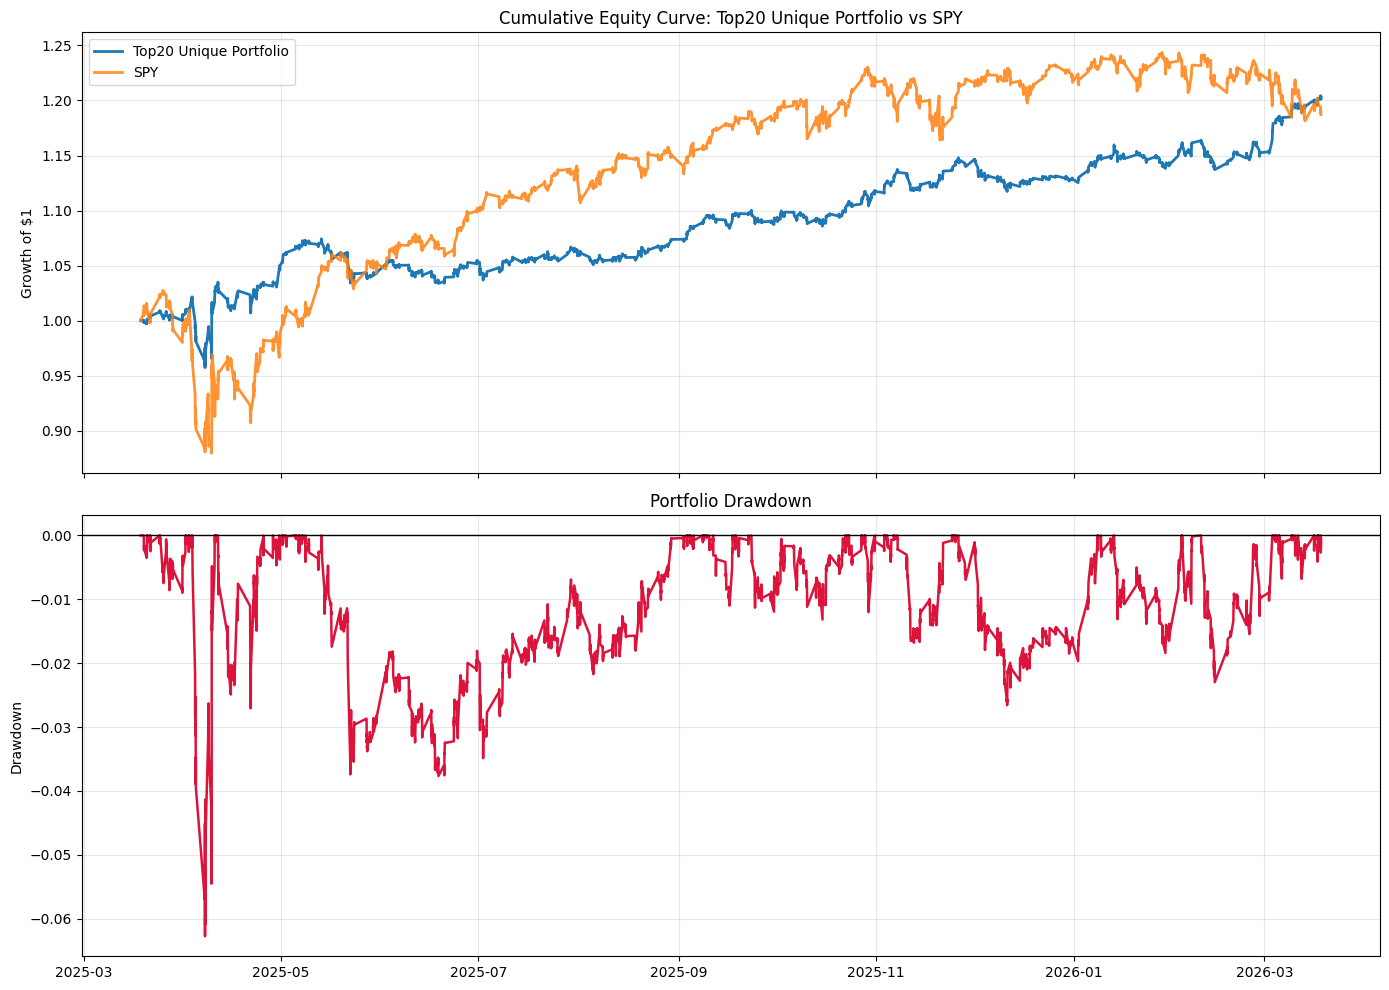

In [25]:
cum = (1 + aligned_df).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(cum.index, cum['p'], label='Top20 Unique Portfolio', linewidth=2)
axes[0].plot(cum.index, cum['b'], label=BENCHMARK_SYMBOL, linewidth=2, alpha=0.85)
axes[0].set_title(f'Cumulative Equity Curve: Top20 Unique Portfolio vs {BENCHMARK_SYMBOL}')
axes[0].set_ylabel('Growth of $1')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(dd_series.index, dd_series.values, color='crimson', linewidth=1.8)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Portfolio Drawdown')
axes[1].set_ylabel('Drawdown')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Notes
- The selected universe comes from the best 1-year in-sample 30/60-minute Kalman configurations, one row per symbol.
- This notebook can be rerun with a different historical window by changing `START_DT` and `END_DT`.
- You can export `summary` and `asset_level` to CSV for reporting or portfolio construction pipelines.

In [24]:
# Compact diagnostics snapshot
key_rows = [
    'Portfolio Total Return',
    'Benchmark Total Return',
    'Portfolio CAGR',
    'Benchmark CAGR',
    'Sharpe',
    'Sortino',
    'Calmar',
    'Max Drawdown',
    'Beta',
    'Alpha (Ann, Jensen)',
    'Information Ratio',
    'Observation Bars',
    'Start',
    'End'
]

diag = pd.Series(metrics).loc[key_rows]
print(diag.to_string())

Portfolio Total Return                     0.201882
Benchmark Total Return                     0.187188
Portfolio CAGR                             0.202641
Benchmark CAGR                             0.187888
Sharpe                                     1.570679
Sortino                                    2.057129
Calmar                                     3.230015
Max Drawdown                              -0.062737
Beta                                       0.103001
Alpha (Ann, Jensen)                        0.133841
Information Ratio                           0.00409
Observation Bars                               3263
Start                     2025-03-18 13:30:00-04:00
End                       2026-03-18 13:00:00-04:00
